<a href="https://colab.research.google.com/github/SereneSorceress/20241cai0223-NVIDIA-INTERNSHIP/blob/main/student_performance_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3922 - loss: 0.7855 - val_accuracy: 0.6500 - val_loss: 0.6630
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7234 - loss: 0.6016 - val_accuracy: 0.6812 - val_loss: 0.6032
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7266 - loss: 0.5556 - val_accuracy: 0.6812 - val_loss: 0.5795
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7281 - loss: 0.5325 - val_accuracy: 0.7125 - val_loss: 0.5647
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7484 - loss: 0.5174 - val_accuracy: 0.7312 - val_loss: 0.5561
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7484 - loss: 0.5077 - val_accuracy: 0.7250 - val_loss: 0.5509
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7484 - loss: 0.5012 - val_accuracy: 0.7375 - val_loss: 0.5464
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7594 - loss: 0.4951 - val_accuracy: 0.7375 - val_loss

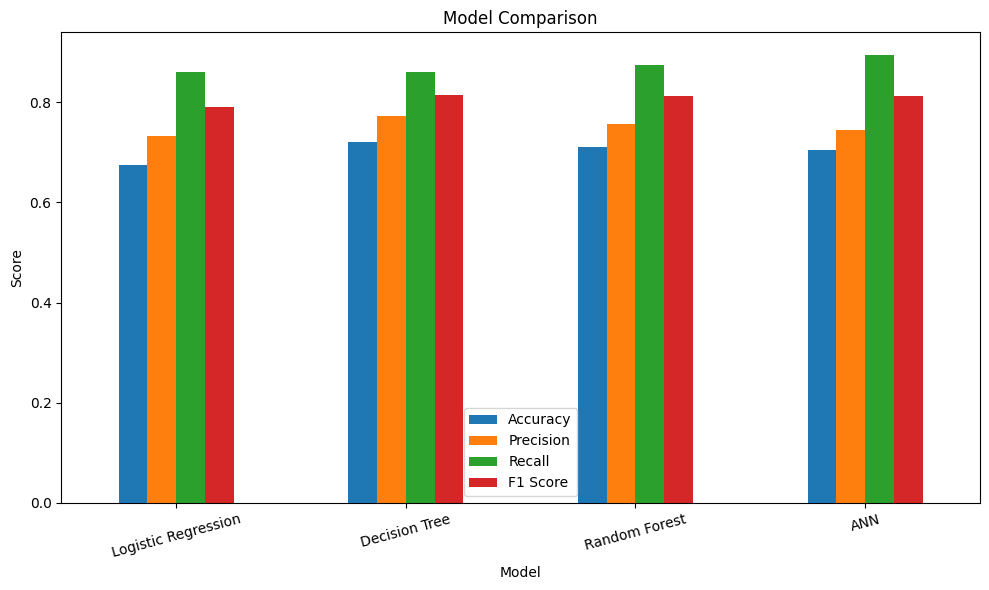

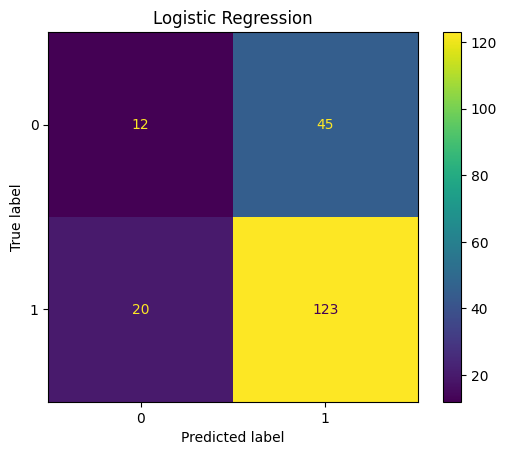

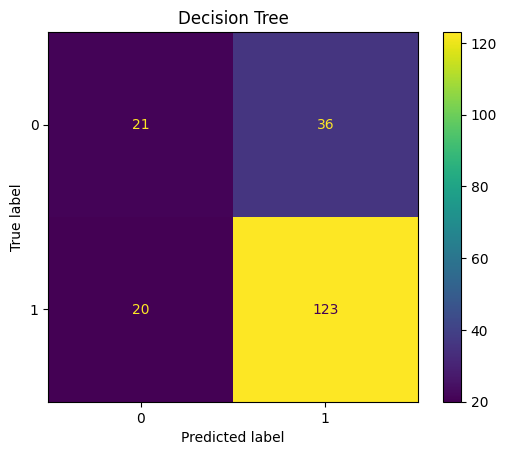

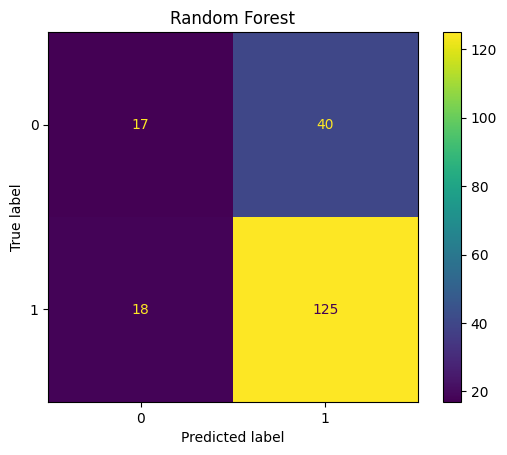

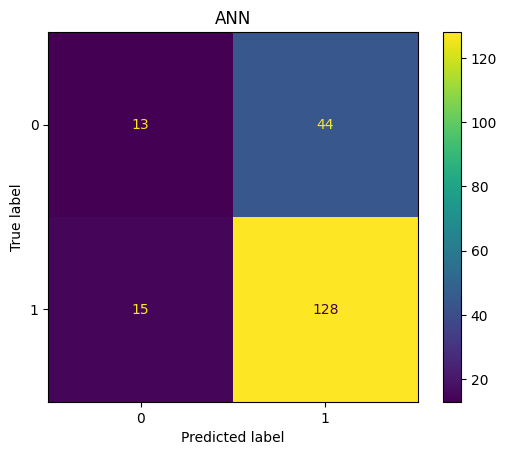

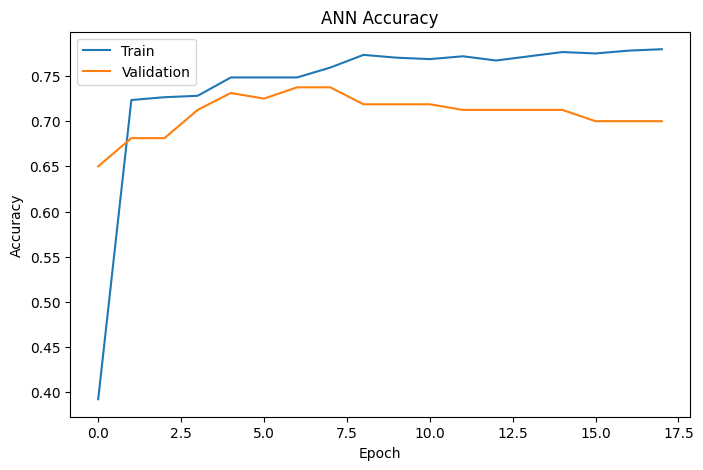

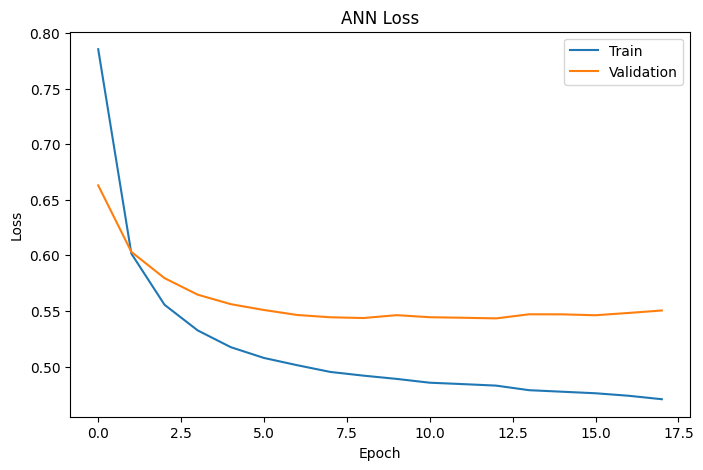

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
=====
df = pd.read_csv("StudentsPerformance.csv")

df["Average"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# 1 = Pass, 0 = Fail
df["Performance"] = (df["Average"] >= 60).astype(int)


X = df.drop(
    ["math score",
     "reading score",
     "writing score",
     "Average",
     "Performance"],
    axis=1
)

y = df["Performance"]

categorical_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

X_train_ann = preprocessor.fit_transform(X_train)
X_test_ann = preprocessor.transform(X_test)

X_train_ann = X_train_ann.toarray()
X_test_ann = X_test_ann.toarray()

scaler = StandardScaler()

X_train_ann = scaler.fit_transform(X_train_ann)
X_test_ann = scaler.transform(X_test_ann)

ann = Sequential([
    Dense(32, activation='relu',
          input_shape=(X_train_ann.shape[1],)),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    X_train_ann,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

ann_pred = ann.predict(X_test_ann)
ann_pred = (ann_pred > 0.5).astype(int)

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "ANN"
        ],
        "Accuracy": [
            evaluate(y_test, lr_pred)[0],
            evaluate(y_test, dt_pred)[0],
            evaluate(y_test, rf_pred)[0],
            evaluate(y_test, ann_pred)[0]
        ],
        "Precision": [
            evaluate(y_test, lr_pred)[1],
            evaluate(y_test, dt_pred)[1],
            evaluate(y_test, rf_pred)[1],
            evaluate(y_test, ann_pred)[1]
        ],
        "Recall": [
            evaluate(y_test, lr_pred)[2],
            evaluate(y_test, dt_pred)[2],
            evaluate(y_test, rf_pred)[2],
            evaluate(y_test, ann_pred)[2]
        ],
        "F1 Score": [
            evaluate(y_test, lr_pred)[3],
            evaluate(y_test, dt_pred)[3],
            evaluate(y_test, rf_pred)[3],
            evaluate(y_test, ann_pred)[3]
        ]
    }
)

print("\nMODEL COMPARISON")
print(results)

results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "ANN": ann_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(name)
    plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()